# Simulation of a Two-Level Quantum System

## Objective

The goal of this notebook is to implement and study the dynamics of qubit.

This notebook introduces the basics:

- Pauli matrices
- Hamiltonian dynamics
- Schrödinger evolution
- Matrix exponentials

## The Qubit

We all know that a qubit is represented by a state vector in a superposition of states

$$
|\psi\rangle=
\alpha|0\rangle+\beta|1\rangle
$$

where

$$
|\alpha|^2+|\beta|^2=1
$$

But what is bieutiful in quantum mecanics is the specific intrinsic property that allows the states vector to be in those state in what we call spin-1/2.

The evolution of a closed quantum system is governed by the Schrödinger equation

$$
i\frac{d}{dt}|\psi(t)\rangle
=
H|\psi(t)\rangle
$$

For a time-independent Hamiltonian,

$$
U(t)=e^{-iHt}
$$

why we focus on $U(t)$, because this is the engine of our dynamics it is called the propergator

In [71]:
import sys
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

root_path = Path.cwd().parent
sys.path.append(str(root_path / "src"))

from hamiltonians import sigma_x, sigma_y, sigma_z, hamiltonian
from evolution import evolution_operator

print("Sigma X:\n", sigma_x)
print("Sigma Y:\n", sigma_y)
print("Sigma Z:\n", sigma_z)

Sigma X:
 [[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
Sigma Y:
 [[ 0.+0.j -0.-1.j]
 [ 0.+1.j  0.+0.j]]
Sigma Z:
 [[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]


The Pauli matrices generate the Lie algebra

$$
\mathfrak{su}(2)
$$

They satisfy

$$
[\sigma_x,\sigma_y]
=
2i\sigma_z
$$

and cyclic permutations.

In [72]:
comm = sigma_x @ sigma_y - sigma_y @ sigma_x
print(comm)
assert np.allclose(comm, 2j * sigma_z), "Commutator is incorrect."

[[0.+2.j 0.+0.j]
 [0.+0.j 0.-2.j]]


## Hamiltonian

We consider

$$
H=
\frac{\omega}{2}\sigma_z
$$

This corresponds to a spin-1/2 particle in a magnetic field aligned with the z-axis.

In [73]:
omega = 1.0

H = hamiltonian(omega, 0, 0)

print(H)

[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]


The corresponding unitary evolution operator is

$$
U(t)=e^{-iHt}
$$

Called this the propagator.

In [74]:
U = evolution_operator(H, time=1.0)

print(U)

[[0.54030231+0.j         0.        -0.84147098j]
 [0.        -0.84147098j 0.54030231+0.j        ]]


The states evolution is calculated simply by multiplying the propagator by our initial state
$$
\psi(t)=U(t)  \psi_0
$$

In [75]:
psi_0 = np.array([1,0])

psi_t = U @ psi_0

print(psi_t)

[0.54030231+0.j         0.        -0.84147098j]


The initial state evolves according to the Hamiltonian dynamics generated by H.

In [76]:
times = np.linspace(0,10,500)

prob0 = []
prob1 = []

for t in times:
    U = evolution_operator(H, time=t)
    psi_t = U @ psi_0
    prob0.append(np.abs(psi_t[0])**2)
    prob1.append(np.abs(psi_t[1])**2)

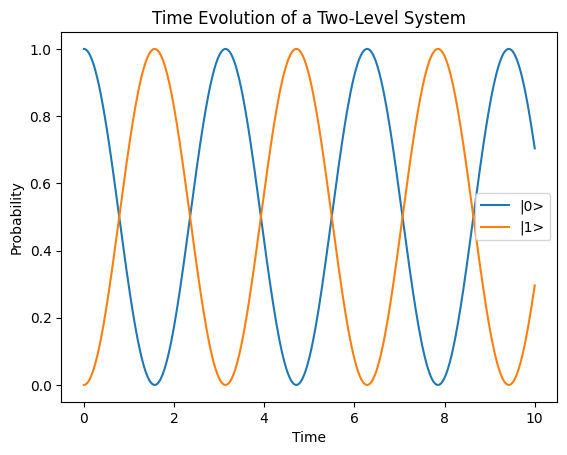

In [77]:
plt.plot(times, prob0, label="|0>")
plt.plot(times, prob1, label="|1>")
plt.xlabel("Time")
plt.ylabel("Probability")
plt.title("Time Evolution of a Two-Level System")
plt.legend()

The oscillatory behaviour reflects coherent quantum evolution.

The probabilities remain normalized throughout the simulation.

## Discussion

In this notebook we implemented a numerical simulation of a single qubit.

We verified:

- Pauli matrix algebra
- Hamiltonian construction
- Unitary evolution
- State propagation

These tools form the basis for quantum control problems.

In future notebooks we will introduce external control fields and investigate the synthesis of quantum gates through pulse engineering.